In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


# 0. Import libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")


# 1. Load Data

In [13]:
train_path = "/kaggle/input/competitions/titanic/train.csv"
test_path = "/kaggle/input/competitions/titanic/test.csv"
gender_path = "/kaggle/input/competitions/titanic/gender_submission.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
gender_submission = pd.read_csv(gender_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

display(train.head())
display(test.head())


Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# 2. Explore the data

In [14]:
print("Train information:")
train.info()

Train information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [15]:
print("Train columns:")
print(train.columns.tolist())

print("\nFirst 5 rows:")
display(train.head())

print("\nStatistical summary:")
display(train.describe())


Train columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Statistical summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 3. Find missing Values

In [16]:
print("Missing values in training data:")
display(train.isnull().sum())

print("\nMissing values in test data:")
display(test.isnull().sum())


Missing values in training data:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Missing values in test data:


PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

# 4. Explore Survivals

## 4.1 overall survival

Survived
0    549
1    342
Name: count, dtype: int64


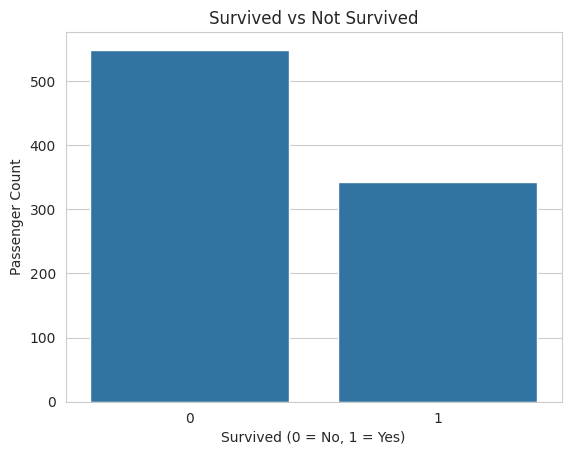

In [17]:
print(train["Survived"].value_counts())

sns.countplot(data=train, x="Survived")
plt.title("Survived vs Not Survived")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Passenger Count")
plt.show()


## 4.2 Male v Female Survival

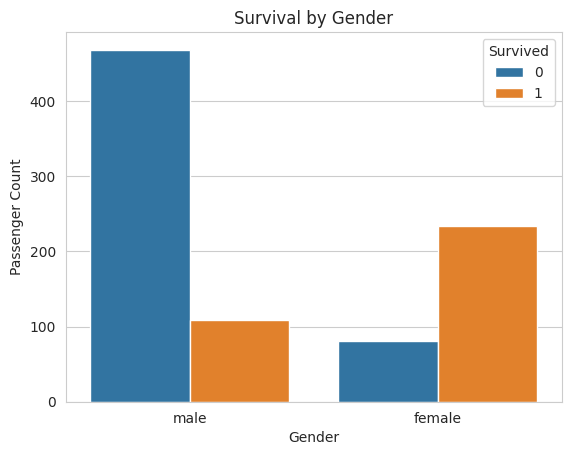

In [18]:
sns.countplot(data=train, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Passenger Count")
plt.show()



## 4.3 survival by gender 

In [19]:
gender_survival = train.groupby(["Sex", "Survived"]).size().unstack()

display(gender_survival)


Survived,0,1
Sex,,
female,81,233
male,468,109


## 4.4 by percentage

Survival percentage:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


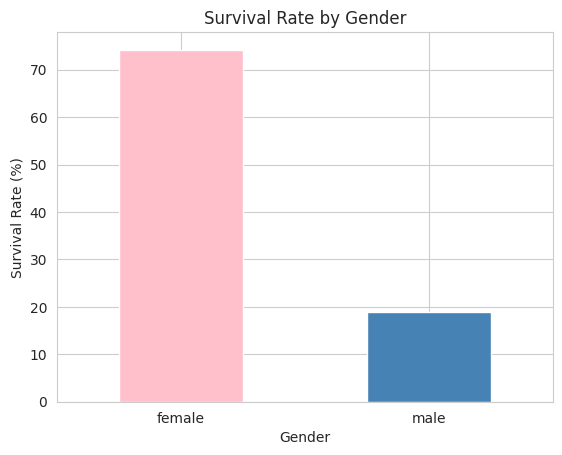

In [21]:
survival_rate = train.groupby("Sex")["Survived"].mean() * 100

print("Survival percentage:")
print(survival_rate)

survival_rate.plot(kind="bar", color=["pink", "steelblue"])

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.show()


# 5. Exploring more data

## 5.1 exploring by passenger class

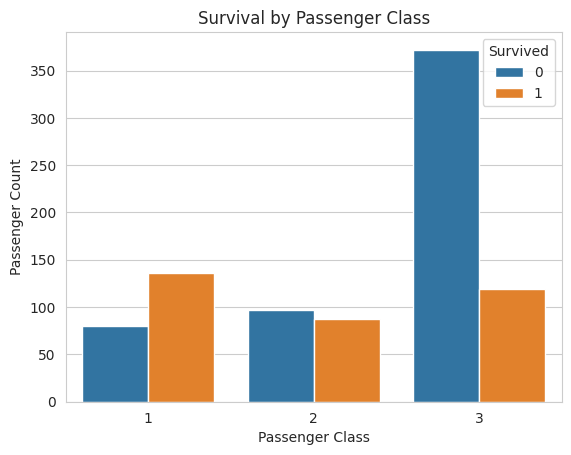

In [22]:
sns.countplot(data=train, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Passenger Count")
plt.show()


## 5.2 age distribution

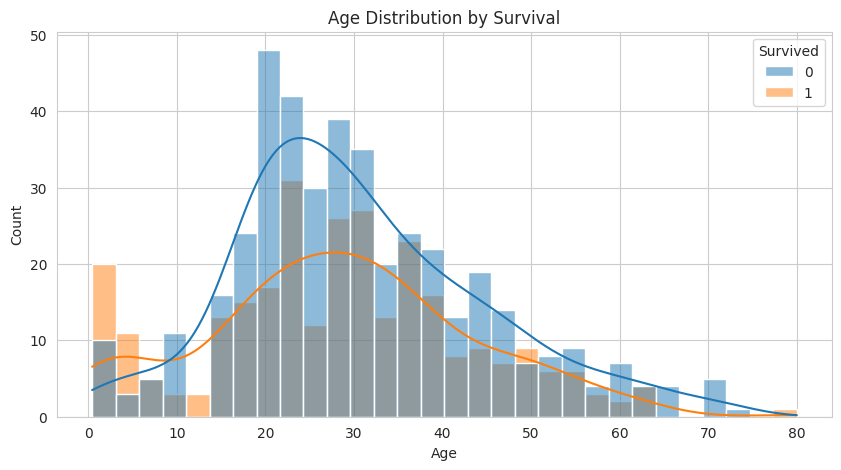

In [23]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=train,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True
)

plt.title("Age Distribution by Survival")
plt.show()


## 5.3 correlation

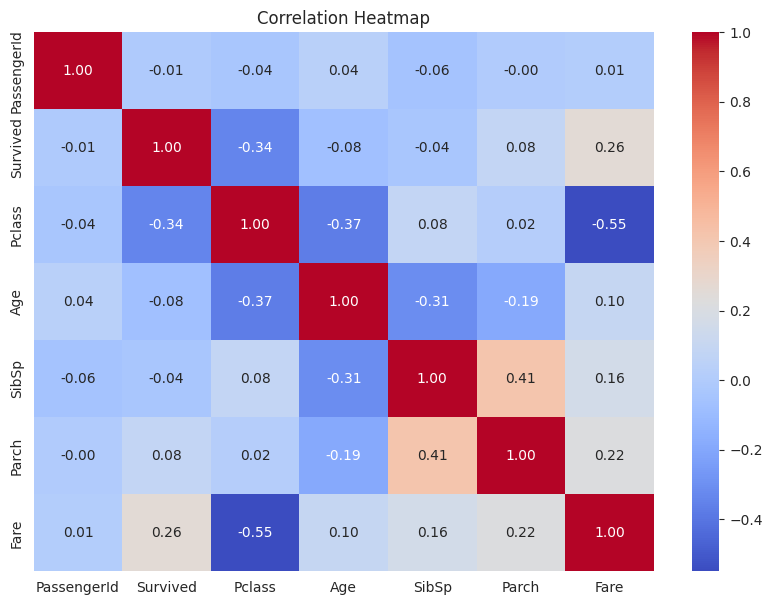

In [24]:
numeric_columns = train.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


# 6. data cleaning

In [25]:
train_clean = train.copy()
test_clean = test.copy()

# Fill Age with median
train_clean["Age"] = train_clean["Age"].fillna(train_clean["Age"].median())
test_clean["Age"] = test_clean["Age"].fillna(train_clean["Age"].median())

# Fill Embarked with most common value
train_clean["Embarked"] = train_clean["Embarked"].fillna(
    train_clean["Embarked"].mode()[0]
)

# Fill Fare with median
test_clean["Fare"] = test_clean["Fare"].fillna(test_clean["Fare"].median())

# Cabin has many missing values, so drop it
train_clean = train_clean.drop(columns=["Cabin"])
test_clean = test_clean.drop(columns=["Cabin"])

print("Missing values after cleaning:")
display(train_clean.isnull().sum())


Missing values after cleaning:


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# 7. feature engineering

In [28]:
# Create FamilySize and IsAlone
for df in [train_clean, test_clean]:
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Create Title from Name
for df in [train_clean, test_clean]:
    df["Title"] = df["Name"].str.extract(
        r",\s*([^.]*)\.",
        expand=False
    ).str.strip()

# Check that Title was created
print("Train titles:")
print(train_clean["Title"].value_counts())

print("\nTest titles:")
print(test_clean["Title"].value_counts())

# Keep common titles and group the rest as Rare
common_titles = ["Mr", "Miss", "Mrs", "Master"]

for df in [train_clean, test_clean]:
    df["Title"] = df["Title"].apply(
        lambda x: x if x in common_titles else "Rare"
    )

print("\nTitles after grouping:")
print(train_clean["Title"].value_counts())


Train titles:
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

Test titles:
Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

Titles after grouping:
Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64


## feature selection


In [31]:
for df in [train_clean, test_clean]:
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)


In [32]:
for df in [train_clean, test_clean]:
    df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.", expand=False)

print(train_clean["Title"].value_counts())


Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


## group uncommon titles

In [33]:
common_titles = ["Mr", "Miss", "Mrs", "Master"]

for df in [train_clean, test_clean]:
    df["Title"] = df["Title"].apply(
        lambda x: x if x in common_titles else "Rare"
    )


# 8. categorical $\rightarrow$ numerical data

In [34]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "Title"
]

X = train_clean[features]
y = train_clean["Survived"]

X_test = test_clean[features]

X = pd.get_dummies(X, columns=["Sex", "Embarked", "Title"], drop_first=True)
X_test = pd.get_dummies(
    X_test,
    columns=["Sex", "Embarked", "Title"],
    drop_first=True
)

# Make sure train and test have exactly the same columns
X_test = X_test.reindex(columns=X.columns, fill_value=0)

print("Training features:")
display(X.head())

print("Feature shape:", X.shape)
print("Test feature shape:", X_test.shape)


Training features:


,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,22.0,1,0,7.2500,2,0,True,False,True,False,True,False,False
1,1,38.0,1,0,71.2833,2,0,False,False,False,False,False,True,False
2,3,26.0,0,0,7.9250,1,1,False,False,True,True,False,False,False
3,1,35.0,1,0,53.1000,2,0,False,False,True,False,False,True,False
4,3,35.0,0,0,8.0500,1,1,True,False,True,False,True,False,False


Feature shape: (891, 14)
Test feature shape: (418, 14)


# 9. split training data

In [35]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Validation data:", X_valid.shape)


Training data: (712, 14)
Validation data: (179, 14)


# 10. train logistic model

In [36]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)


LogisticRegression(max_iter=1000, random_state=42)

# 11. evaluate model

In [37]:
y_pred = model.predict(X_valid)

accuracy = accuracy_score(y_valid, y_pred)

print("Validation Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_valid, y_pred))


Validation Accuracy: 0.8156424581005587

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



`confusion Matrix`

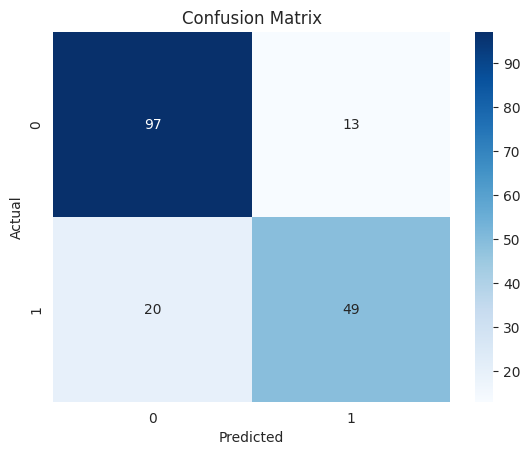

In [38]:
cm = confusion_matrix(y_valid, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 12. Train on complete dataset

In [39]:
final_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

final_model.fit(X, y)


LogisticRegression(max_iter=1000, random_state=42)

# 13. predict kaggle test data

In [40]:
test_predictions = final_model.predict(X_test)

print("Number of predictions:", len(test_predictions))
print("Predicted survivors:", test_predictions.sum())
print("Predicted non-survivors:", (test_predictions == 0).sum())


Number of predictions: 418
Predicted survivors: 165
Predicted non-survivors: 253


# 14. create `submission.csv`

In [41]:
submission = pd.DataFrame({
    "PassengerId": test_clean["PassengerId"],
    "Survived": test_predictions.astype(int)
})

submission.to_csv(
    "/kaggle/working/submission.csv",
    index=False
)

display(submission.head(10))


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


checking the file

In [42]:
print("Submission shape:", submission.shape)
print("Submission file created successfully!")

display(pd.read_csv("/kaggle/working/submission.csv").head())


Submission shape: (418, 2)
Submission file created successfully!


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
